## Key Analyses:

- Distribution of Reviewer_Score (your target variable for a regression task? Or binarize it for classification?).

- Analyze Negative_Review and Positive_Review text (word clouds, common phrases).

- Correlation between numerical features (Average_Score, Total_Number_of_Reviews, Review_Total_Negative_Word_Counts, etc.) and the target.

- Geographic analysis using lat and lng.

- Analyze Reviewer_Nationality for potential bias.

- Handle missing values (especially in lat/lng).

- Understand the Tags column structure.

In [1]:
# notebooks/EDAs/primary/01_primary_eda.ipynb

# =============================================
# TRIPMIND - PRIMARY EXPLORATORY DATA ANALYSIS
# =============================================
# Phase 1: Foundation Analysis
# Focus: Data Structure, Quality, Basic Distributions
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set up plotting style for professional look
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("🔍 TRIPMIND - PRIMARY EDA STARTED")
print("=" * 50)

🔍 TRIPMIND - PRIMARY EDA STARTED


In [2]:
# SECTION 1: DATA LOADING & INITIAL ASSESSMENT
# ============================================

print("📥 SECTION 1: DATA LOADING & INITIAL ASSESSMENT")
print("-" * 50)

# Load the dataset
try:
    # Adjust path based on your actual data location
    data_path = '../../../dataset/raw_dataset/Hotel_Reviews.csv'  # Update this path as needed
    df = pd.read_csv(data_path)
    print("✅ Data loaded successfully!")
except FileNotFoundError:
    print("❌ Data file not found. Please check the path.")
    # Alternative: Use relative path from project root
    data_path = os.path.join(os.path.dirname(os.getcwd()), 'dataset', 'raw_dataset', 'Hotel_Reviews.csv')
    df = pd.read_csv(data_path)

# 1.1 Basic Dataset Information
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\n📋 Column Names and Data Types:")
print("=" * 40)
df_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
display(df_info)

# 1.2 First Look at the Data
print("\n👀 First 5 Rows of the Dataset:")
print("=" * 40)
display(df.head())

print("\n👀 Last 5 Rows of the Dataset:")
print("=" * 40)
display(df.tail())

# 1.3 Memory Usage
print(f"\n💾 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📥 SECTION 1: DATA LOADING & INITIAL ASSESSMENT
--------------------------------------------------
✅ Data loaded successfully!

📊 Dataset Shape: (515738, 17)
Number of rows: 515,738
Number of columns: 17

📋 Column Names and Data Types:


,Column,Data Type,Non-Null Count,Null Count,Null Percentage
Hotel_Address,Hotel_Address,object,515738,0,0.00
Additional_Number_of_Scoring,Additional_Number_of_Scoring,int64,515738,0,0.00
Review_Date,Review_Date,object,515738,0,0.00
Average_Score,Average_Score,float64,515738,0,0.00
Hotel_Name,Hotel_Name,object,515738,0,0.00
Reviewer_Nationality,Reviewer_Nationality,object,515738,0,0.00
Negative_Review,Negative_Review,object,515738,0,0.00
Review_Total_Negative_Word_Counts,Review_Total_Negative_Word_Counts,int64,515738,0,0.00
Total_Number_of_Reviews,Total_Number_of_Reviews,int64,515738,0,0.00
Positive_Review,Positive_Review,object,515738,0,0.00



👀 First 5 Rows of the Dataset:


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968



👀 Last 5 Rows of the Dataset:


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,2,8,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,11,12,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,0,3,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,25,3,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677
515737,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/9/2015,8.1,Atlantis Hotel Vienna,Hungary,I was in 3rd floor It didn t work Free Wife,13,2823,staff was very kind,6,1,8.3,"[' Leisure trip ', ' Family with young childre...",725 day,48.203745,16.335677



💾 Memory Usage: 427.89 MB




🔍 SECTION 2: DATA QUALITY ASSESSMENT
--------------------------------------------------
📉 MISSING VALUES ANALYSIS
Columns with missing values:


,Missing Count,Missing Percentage
lng,3268,0.633655
lat,3268,0.633655


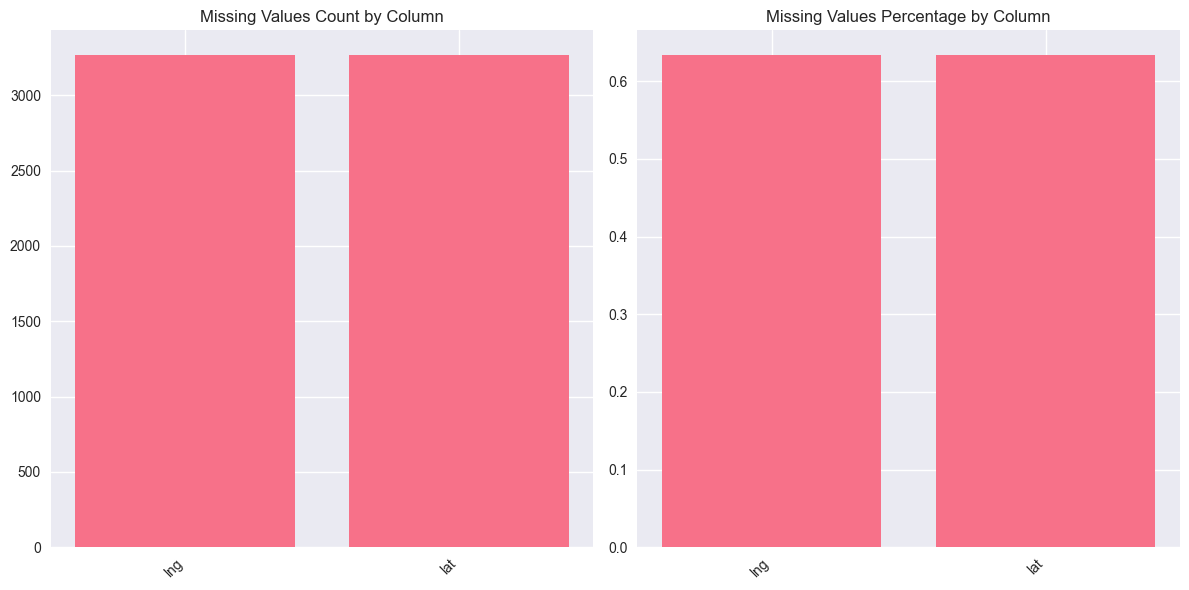


🔍 DUPLICATE ANALYSIS
Total duplicate rows: 526 (0.10%)

Sample of duplicate rows:


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
23704,100 110 Euston Road Camden London NW1 2AJ Unit...,728,2/25/2017,8.9,Pullman London St Pancras,China,none,2,3168,good location and super nice staff room is bi...,13,39,9.6,"[' Business trip ', ' Solo traveler ', ' Class...",159 day,51.528677,-0.128349
61876,16 22 Great Russell Street Camden London WC1B ...,300,7/27/2017,9.0,The Bloomsbury Hotel,Israel,No Negative,0,1254,The attention received by Sebastian and his t...,12,4,9.6,"[' Leisure trip ', ' Couple ', ' Superior Doub...",7 days,51.517167,-0.129053
68967,167 rue de Rome 17th arr 75017 Paris France,11,6/23/2017,6.8,Villa Eugenie,Netherlands,Location is very old not invested in past yea...,41,165,Location is central accessible by train parki...,12,24,4.6,"[' Business trip ', ' Solo traveler ', ' Singl...",41 days,48.887128,2.314205
68968,167 rue de Rome 17th arr 75017 Paris France,11,4/27/2017,6.8,Villa Eugenie,United Kingdom,This hotel I don t think so is 4 star B B hav...,93,165,Nothing,2,10,2.5,"[' Business trip ', ' Solo traveler ', ' Singl...",98 days,48.887128,2.314205
68969,167 rue de Rome 17th arr 75017 Paris France,11,3/4/2017,6.8,Villa Eugenie,South Africa,The staff were not helpful at all It took us ...,69,165,Near bus terminal,4,4,5.0,"[' Leisure trip ', ' Couple ', ' Twin Room ', ...",152 day,48.887128,2.314205



📝 DATA TYPE VALIDATION
Review_Date: Sample values - ['8/3/2017', '8/3/2017', '7/31/2017']

Data type consistency check:
----------------------------------------
✅ Hotel_Address has consistent data type: object
✅ Additional_Number_of_Scoring has consistent data type: int64
✅ Review_Date has consistent data type: object
✅ Average_Score has consistent data type: float64
✅ Hotel_Name has consistent data type: object
✅ Reviewer_Nationality has consistent data type: object
✅ Negative_Review has consistent data type: object
✅ Review_Total_Negative_Word_Counts has consistent data type: int64
✅ Total_Number_of_Reviews has consistent data type: int64
✅ Positive_Review has consistent data type: object
✅ Review_Total_Positive_Word_Counts has consistent data type: int64
✅ Total_Number_of_Reviews_Reviewer_Has_Given has consistent data type: int64
✅ Reviewer_Score has consistent data type: float64
✅ Tags has consistent data type: object
✅ days_since_review has consistent data type: object
✅ lat has 

In [13]:
# SECTION 2: DATA QUALITY ASSESSMENT
# ==================================

print("\n\n🔍 SECTION 2: DATA QUALITY ASSESSMENT")
print("-" * 50)

# 2.1 Comprehensive Missing Values Analysis
print("📉 MISSING VALUES ANALYSIS")
print("=" * 40)

missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

# Display only columns with missing values
missing_data_exists = missing_df[missing_df['Missing Count'] > 0]
if len(missing_data_exists) > 0:
    print("Columns with missing values:")
    display(missing_data_exists)
else:
    print("✅ No missing values found!")

# Visualize missing data
if len(missing_data_exists) > 0:
    plt.figure(figsize=(12, 6))
    missing_plot_data = missing_data_exists[missing_data_exists['Missing Percentage'] > 0]
    
    if len(missing_plot_data) > 0:
        plt.subplot(1, 2, 1)
        plt.bar(missing_plot_data.index, missing_plot_data['Missing Count'])
        plt.title('Missing Values Count by Column')
        plt.xticks(rotation=45, ha='right')
        
        plt.subplot(1, 2, 2)
        plt.bar(missing_plot_data.index, missing_plot_data['Missing Percentage'])
        plt.title('Missing Values Percentage by Column')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("✅ No significant missing values to visualize!")

# 2.2 Duplicate Analysis
print(f"\n🔍 DUPLICATE ANALYSIS")
print("=" * 40)
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates} ({total_duplicates/len(df)*100:.2f}%)")

if total_duplicates > 0:
    print("\nSample of duplicate rows:")
    display(df[df.duplicated()].head())
else:
    print("✅ No duplicate rows found!")

# 2.3 Data Type Validation
print(f"\n📝 DATA TYPE VALIDATION")
print("=" * 40)

# Check date columns
date_columns = ['Review_Date']
for col in date_columns:
    if col in df.columns:
        print(f"{col}: Sample values - {df[col].head(3).tolist()}")

# Check for mixed data types
print("\nData type consistency check:")
print("-" * 40)
all_consistent = True  # flag to track if all columns are consistent

for col in df.columns:
    if df[col].apply(type).nunique() > 1:
        all_consistent = False
        print(f"⚠️  Mixed types in {col}: {df[col].apply(type).value_counts().to_dict()}")
    else:
        print(f"✅ {col} has consistent data type: {df[col].dtype}")
print("=" * 65)
if all_consistent:
    print("All columns have consistent data types. No mixed types found.")
print("=" * 65)
print("🎉 Data type consistency check complete")

In [ ]:
# SECTION 3: BASIC STATISTICAL ANALYSIS
# =====================================

print("\n\n📈 SECTION 3: BASIC STATISTICAL ANALYSIS")
print("-" * 50)

# 3.1 Numerical Features Summary
print("🔢 NUMERICAL FEATURES SUMMARY")
print("=" * 40)

numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"Found {len(numerical_cols)} numerical columns:")

if len(numerical_cols) > 0:
    print("Numerical columns:", list(numerical_cols))
    
    # Basic statistics
    numerical_stats = df[numerical_cols].describe()
    display(numerical_stats)
    
    # Additional numerical insights
    print("\n📊 Additional Numerical Insights:")
    numerical_insights = pd.DataFrame({
        'Variance': df[numerical_cols].var(),
        'Skewness': df[numerical_cols].skew(),
        'Kurtosis': df[numerical_cols].kurtosis()
    }).round(3)
    display(numerical_insights)
else:
    print("❌ No numerical columns found!")

# 3.2 Categorical Features Summary
print(f"\n📝 CATEGORICAL FEATURES SUMMARY")
print("=" * 40)

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Found {len(categorical_cols)} categorical columns:")

if len(categorical_cols) > 0:
    print("Categorical columns:", list(categorical_cols))
    
    categorical_summary = []
    for col in categorical_cols:
        unique_count = df[col].nunique()
        most_common = df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'N/A'
        most_common_count = (df[col] == most_common).sum()
        most_common_pct = (most_common_count / len(df)) * 100
        
        categorical_summary.append({
            'Column': col,
            'Unique Values': unique_count,
            'Most Common Value': str(most_common)[:50] + '...' if len(str(most_common)) > 50 else str(most_common),
            'Most Common Count': most_common_count,
            'Most Common %': f"{most_common_pct:.2f}%"
        })
    
    categorical_df = pd.DataFrame(categorical_summary)
    display(categorical_df)
    
    # Show value counts for key categorical columns
    key_categorical = ['Reviewer_Nationality', 'Hotel_Name', 'Negative_Review', 'Positive_Review']
    for col in key_categorical:
        if col in df.columns:
            print(f"\n📋 Top 10 values for '{col}':")
            display(df[col].value_counts().head(10))
else:
    print("❌ No categorical columns found!")



📈 SECTION 3: BASIC STATISTICAL ANALYSIS
--------------------------------------------------
🔢 NUMERICAL FEATURES SUMMARY
Found 9 numerical columns:
Numerical columns: ['Additional_Number_of_Scoring', 'Average_Score', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'lat', 'lng']


,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233



📊 Additional Numerical Insights:


,Variance,Skewness,Kurtosis
Additional_Number_of_Scoring,250538.757,2.208,5.752
Average_Score,0.300,-0.545,0.422
Review_Total_Negative_Word_Counts,881.545,4.408,31.414
Total_Number_of_Reviews,5370643.416,2.086,6.421
Review_Total_Positive_Word_Counts,475.422,4.191,32.943
Total_Number_of_Reviews_Reviewer_Has_Given,121.887,5.088,51.479
Reviewer_Score,2.683,-1.193,0.971
lat,12.015,-1.404,0.654
lng,20.971,1.896,2.779



📝 CATEGORICAL FEATURES SUMMARY
Found 8 categorical columns:
Categorical columns: ['Hotel_Address', 'Review_Date', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Positive_Review', 'Tags', 'days_since_review']


...


📋 Top 10 values for 'Negative_Review':


Negative_Review
No Negative    127890
 Nothing        14295
 Nothing         4236
 nothing         2225
 N A             1037
 None             984
                  849
 N a              509
 Breakfast        407
 Small room       373
Name: count, dtype: int64


📋 Top 10 values for 'Positive_Review':


Positive_Review
No Positive        35946
 Location           9222
 Everything         2284
 location           1677
 Nothing            1243
 The location       1126
 Great location     1047
 Good location       927
 Location            915
 Everything          613
Name: count, dtype: int64

: 